In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load Dataset Files

Let's load both dataset files and examine their contents.

In [2]:
# Define file paths
formatted_data_path = 'data/Multi Cancer/formatted_data.npz'
adenocarcinoma_path = 'data/Multi Cancer/adenocarcinoma_dataset.npz'

# Check if files exist
import os
print("📁 Checking file availability:")
print(f"  formatted_data.npz: {'✅ Found' if os.path.exists(formatted_data_path) else '❌ Not found'}")
print(f"  adenocarcinoma_dataset.npz: {'✅ Found' if os.path.exists(adenocarcinoma_path) else '❌ Not found'}")

📁 Checking file availability:
  formatted_data.npz: ✅ Found
  adenocarcinoma_dataset.npz: ✅ Found


## 2. Explore formatted_data.npz

In [5]:
# Load formatted_data.npz
if os.path.exists(formatted_data_path):
    print("📊 Loading formatted_data.npz...")
    print("=" * 60)
    
    formatted_data = np.load(formatted_data_path, allow_pickle=True)
    
    # Display available keys
    print("🔑 Available keys in formatted_data.npz:")
    for key in formatted_data.files:
        print(f"  • {key}")
    
    # Load arrays
    formatted_images = formatted_data['images']
    formatted_labels1 = formatted_data['labels_id']  # class ids
    formatted_labels2 = formatted_data['binary_labels']  # binary labels (0=benign, 1=malignant)
    formatted_domain_text = formatted_data['domain_text']
    formatted_subdomain_text = formatted_data['labels_text']  # original class names
    
    print(f"\n📈 Dataset Structure:")
    print(f"  Images shape: {formatted_images.shape}")
    print(f"  Labels1 (class ids) shape: {formatted_labels1.shape}")
    print(f"  Labels2 (binary) shape: {formatted_labels2.shape}")
    print(f"  Domain text length: {len(formatted_domain_text)}")
    print(f"  Sub-domain text length: {len(formatted_subdomain_text)}")
    
else:
    print("❌ formatted_data.npz not found!")

📊 Loading formatted_data.npz...
🔑 Available keys in formatted_data.npz:
  • images
  • labels_text
  • labels_id
  • binary_labels
  • domain_text
  • domain_id

📈 Dataset Structure:
  Images shape: (115002, 224, 224, 3)
  Labels1 (class ids) shape: (115002,)
  Labels2 (binary) shape: (115002,)
  Domain text length: 115002
  Sub-domain text length: 115002

📈 Dataset Structure:
  Images shape: (115002, 224, 224, 3)
  Labels1 (class ids) shape: (115002,)
  Labels2 (binary) shape: (115002,)
  Domain text length: 115002
  Sub-domain text length: 115002


In [7]:
# Analyze labels in formatted_data.npz
if os.path.exists(formatted_data_path):
    print("🏷️ Label Analysis - formatted_data.npz")
    print("=" * 60)
    
    # Unique labels1 (class ids)
    unique_labels1 = np.unique(formatted_labels1)
    print(f"\n📊 Labels1 (Class IDs): {unique_labels1}")
    print(f"   Number of unique class IDs: {len(unique_labels1)}")
    
    # Labels1 distribution
    label1_counts = Counter(formatted_labels1)
    print(f"\n📈 Labels1 Distribution:")
    for label, count in sorted(label1_counts.items()):
        percentage = (count / len(formatted_labels1)) * 100
        print(f"   Class ID {label}: {count:,} samples ({percentage:.2f}%)")
    
    # Unique labels2 (binary)
    unique_labels2 = np.unique(formatted_labels2)
    print(f"\n📊 Labels2 (Binary): {unique_labels2}")
    print(f"   0 = benign, 1 = malignant")
    
    # Labels2 distribution
    label2_counts = Counter(formatted_labels2)
    print(f"\n📈 Labels2 Distribution:")
    for label, count in sorted(label2_counts.items()):
        label_name = "Benign" if label == 0 else "Malignant"
        percentage = (count / len(formatted_labels2)) * 100
        print(f"   Label {label} ({label_name}): {count:,} samples ({percentage:.2f}%)")
    
    # Domain information
    unique_domains = sorted(set(formatted_domain_text))
    print(f"\n🏥 Domain Information:")
    print(f"   Unique domains: {len(unique_domains)}")
    for domain in unique_domains:
        print(f"     • {domain}")
    
    # Domain distribution
    domain_counts = Counter(formatted_domain_text)
    print(f"\n📊 Domain Distribution:")
    for domain, count in sorted(domain_counts.items()):
        print(f"   {domain}: {count:,} samples")
    
    # Sub-domain information
    unique_subdomains = sorted(set(formatted_subdomain_text))
    print(f"\n🔬 Sub-domain Information:")
    print(f"   Unique sub-domains: {len(unique_subdomains)}")
    for subdomain in unique_subdomains:
        print(f"     • {subdomain}")

🏷️ Label Analysis - formatted_data.npz

📊 Labels1 (Class IDs): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
   Number of unique class IDs: 23

📈 Labels1 Distribution:
   Class ID 0: 5,000 samples (4.35%)
   Class ID 1: 5,000 samples (4.35%)
   Class ID 2: 5,000 samples (4.35%)
   Class ID 3: 5,000 samples (4.35%)
   Class ID 4: 5,000 samples (4.35%)
   Class ID 5: 5,000 samples (4.35%)
   Class ID 6: 5,000 samples (4.35%)
   Class ID 7: 5,000 samples (4.35%)
   Class ID 8: 5,000 samples (4.35%)
   Class ID 9: 5,000 samples (4.35%)
   Class ID 10: 5,000 samples (4.35%)
   Class ID 11: 5,000 samples (4.35%)
   Class ID 12: 5,000 samples (4.35%)
   Class ID 13: 5,000 samples (4.35%)
   Class ID 14: 5,000 samples (4.35%)
   Class ID 15: 5,000 samples (4.35%)
   Class ID 16: 5,000 samples (4.35%)
   Class ID 17: 5,000 samples (4.35%)
   Class ID 18: 5,000 samples (4.35%)
   Class ID 19: 5,000 samples (4.35%)
   Class ID 20: 5,000 samples (4.35%)
   Class ID 21: 5,0

In [9]:
# Cross-tabulation: Labels by Domain (formatted_data)
if os.path.exists(formatted_data_path):
    print("🔍 Cross-Analysis: Labels by Domain - formatted_data.npz")
    print("=" * 60)
    
    # Create DataFrame for easier analysis
    df_formatted = pd.DataFrame({
        'label1': formatted_labels1,
        'label2': formatted_labels2,
        'domain': formatted_domain_text,
        'subdomain': formatted_subdomain_text
    })
    
    # Labels1 by domain
    print("\n📊 Labels1 (Class ID) distribution by domain:")
    label1_by_domain = pd.crosstab(df_formatted['domain'], df_formatted['label1'], margins=True)
    print(label1_by_domain)
    
    # Labels2 by domain
    print("\n📊 Labels2 (Binary) distribution by domain:")
    label2_by_domain = pd.crosstab(df_formatted['domain'], df_formatted['label2'], margins=True)
    print(label2_by_domain)
    
    # Labels2 by sub-domain
    print("\n📊 Labels2 (Binary) distribution by sub-domain (class name):")
    label2_by_subdomain = pd.crosstab(df_formatted['subdomain'], df_formatted['label2'], margins=True)
    print(label2_by_subdomain)

🔍 Cross-Analysis: Labels by Domain - formatted_data.npz

📊 Labels1 (Class ID) distribution by domain:
label1              0     1     2     3     4     5     6     7     8     9  \
domain                                                                        
ALL              5000  5000  5000  5000     0     0     0     0     0     0   
Brain Cancer        0     0     0     0  5000  5000  5000     0     0     0   
Breast Cancer       0     0     0     0     0     0     0  5000  5000     0   
Cervical Cancer     0     0     0     0     0     0     0     0     0  5000   
Colon Cancer        0     0     0     0     0     0     0     0     0     0   
Kidney Cancer       0     0     0     0     0     0     0     0     0     0   
Lung Cancer         0     0     0     0     0     0     0     0     0     0   
Lymphoma            0     0     0     0     0     0     0     0     0     0   
Oral Cancer         0     0     0     0     0     0     0     0     0     0   
All              5000  5000  

## 3. Explore adenocarcinoma_dataset.npz

In [11]:
# Load adenocarcinoma_dataset.npz
if os.path.exists(adenocarcinoma_path):
    print("📊 Loading adenocarcinoma_dataset.npz...")
    print("=" * 60)
    
    adeno_data = np.load(adenocarcinoma_path, allow_pickle=True)
    
    # Display available keys
    print("🔑 Available keys in adenocarcinoma_dataset.npz:")
    for key in adeno_data.files:
        print(f"  • {key}")
    
    # Load arrays
    adeno_images = adeno_data['images']
    adeno_labels1 = adeno_data['sub_domain']  # class ids (subdomain labels)
    adeno_labels2 = adeno_data['cancer_binary']  # binary labels (cancer_binary_labels)
    adeno_domain_text = adeno_data['domain_text']
    adeno_subdomain_text = adeno_data['sub_domain_text']
    
    print(f"\n📈 Dataset Structure:")
    print(f"  Images shape: {adeno_images.shape}")
    print(f"  Labels1 (class ids) shape: {adeno_labels1.shape}")
    print(f"  Labels2 (binary) shape: {adeno_labels2.shape}")
    print(f"  Domain text length: {len(adeno_domain_text)}")
    print(f"  Sub-domain text length: {len(adeno_subdomain_text)}")
    
else:
    print("❌ adenocarcinoma_dataset.npz not found!")

📊 Loading adenocarcinoma_dataset.npz...
🔑 Available keys in adenocarcinoma_dataset.npz:
  • images
  • sub_domain
  • cancer_binary
  • domain_text
  • sub_domain_text

📈 Dataset Structure:
  Images shape: (40000, 224, 224, 3)
  Labels1 (class ids) shape: (40000,)
  Labels2 (binary) shape: (40000,)
  Domain text length: 40000
  Sub-domain text length: 40000

📈 Dataset Structure:
  Images shape: (40000, 224, 224, 3)
  Labels1 (class ids) shape: (40000,)
  Labels2 (binary) shape: (40000,)
  Domain text length: 40000
  Sub-domain text length: 40000


In [13]:
# Analyze labels in adenocarcinoma_dataset.npz
if os.path.exists(adenocarcinoma_path):
    print("🏷️ Label Analysis - adenocarcinoma_dataset.npz")
    print("=" * 60)
    
    # Unique labels1 (class ids)
    unique_labels1_adeno = np.unique(adeno_labels1)
    print(f"\n📊 Labels1 (Class IDs): {unique_labels1_adeno}")
    print(f"   Number of unique class IDs: {len(unique_labels1_adeno)}")
    
    # Labels1 distribution
    label1_counts_adeno = Counter(adeno_labels1)
    print(f"\n📈 Labels1 Distribution:")
    for label, count in sorted(label1_counts_adeno.items()):
        percentage = (count / len(adeno_labels1)) * 100
        print(f"   Class ID {label}: {count:,} samples ({percentage:.2f}%)")
    
    # Unique labels2 (binary)
    unique_labels2_adeno = np.unique(adeno_labels2)
    print(f"\n📊 Labels2 (Binary): {unique_labels2_adeno}")
    print(f"   0 = benign, 1 = malignant")
    
    # Labels2 distribution
    label2_counts_adeno = Counter(adeno_labels2)
    print(f"\n📈 Labels2 Distribution:")
    for label, count in sorted(label2_counts_adeno.items()):
        label_name = "Benign" if label == 0 else "Malignant"
        percentage = (count / len(adeno_labels2)) * 100
        print(f"   Label {label} ({label_name}): {count:,} samples ({percentage:.2f}%)")
    
    # Domain information
    unique_domains_adeno = sorted(set(adeno_domain_text))
    print(f"\n🏥 Domain Information:")
    print(f"   Unique domains: {len(unique_domains_adeno)}")
    for domain in unique_domains_adeno:
        print(f"     • {domain}")
    
    # Domain distribution
    domain_counts_adeno = Counter(adeno_domain_text)
    print(f"\n📊 Domain Distribution:")
    for domain, count in sorted(domain_counts_adeno.items()):
        print(f"   {domain}: {count:,} samples")
    
    # Sub-domain information
    unique_subdomains_adeno = sorted(set(adeno_subdomain_text))
    print(f"\n🔬 Sub-domain Information:")
    print(f"   Unique sub-domains: {len(unique_subdomains_adeno)}")
    for subdomain in unique_subdomains_adeno:
        print(f"     • {subdomain}")

🏷️ Label Analysis - adenocarcinoma_dataset.npz

📊 Labels1 (Class IDs): [ 7  8 12 13 14 15 16 17]
   Number of unique class IDs: 8

📈 Labels1 Distribution:
   Class ID 7: 5,000 samples (12.50%)
   Class ID 8: 5,000 samples (12.50%)
   Class ID 12: 5,000 samples (12.50%)
   Class ID 13: 5,000 samples (12.50%)
   Class ID 14: 5,000 samples (12.50%)
   Class ID 15: 5,000 samples (12.50%)
   Class ID 16: 5,000 samples (12.50%)
   Class ID 17: 5,000 samples (12.50%)

📊 Labels2 (Binary): [0 1]
   0 = benign, 1 = malignant

📈 Labels2 Distribution:
   Label 0 (Benign): 20,000 samples (50.00%)
   Label 1 (Malignant): 20,000 samples (50.00%)

🏥 Domain Information:
   Unique domains: 4
     • Breast Cancer
     • Colon Cancer
     • Kidney Cancer
     • Lung Cancer

📊 Domain Distribution:
   Breast Cancer: 10,000 samples
   Colon Cancer: 10,000 samples
   Kidney Cancer: 10,000 samples
   Lung Cancer: 10,000 samples

🔬 Sub-domain Information:
   Unique sub-domains: 8
     • breast_benign
     • bre

In [15]:
# Cross-tabulation: Labels by Domain (adenocarcinoma_dataset)
if os.path.exists(adenocarcinoma_path):
    print("🔍 Cross-Analysis: Labels by Domain - adenocarcinoma_dataset.npz")
    print("=" * 60)
    
    # Create DataFrame for easier analysis
    df_adeno = pd.DataFrame({
        'label1': adeno_labels1,
        'label2': adeno_labels2,
        'domain': adeno_domain_text,
        'subdomain': adeno_subdomain_text
    })
    
    # Labels1 by domain
    print("\n📊 Labels1 (Class ID) distribution by domain:")
    label1_by_domain_adeno = pd.crosstab(df_adeno['domain'], df_adeno['label1'], margins=True)
    print(label1_by_domain_adeno)
    
    # Labels2 by domain
    print("\n📊 Labels2 (Binary) distribution by domain:")
    label2_by_domain_adeno = pd.crosstab(df_adeno['domain'], df_adeno['label2'], margins=True)
    print(label2_by_domain_adeno)
    
    # Labels2 by sub-domain
    print("\n📊 Labels2 (Binary) distribution by sub-domain (class name):")
    label2_by_subdomain_adeno = pd.crosstab(df_adeno['subdomain'], df_adeno['label2'], margins=True)
    print(label2_by_subdomain_adeno)

🔍 Cross-Analysis: Labels by Domain - adenocarcinoma_dataset.npz

📊 Labels1 (Class ID) distribution by domain:
label1            7     8    12    13    14    15    16    17    All
domain                                                              
Breast Cancer  5000  5000     0     0     0     0     0     0  10000
Colon Cancer      0     0  5000  5000     0     0     0     0  10000
Kidney Cancer     0     0     0     0  5000  5000     0     0  10000
Lung Cancer       0     0     0     0     0     0  5000  5000  10000
All            5000  5000  5000  5000  5000  5000  5000  5000  40000

📊 Labels2 (Binary) distribution by domain:
label2             0      1    All
domain                            
Breast Cancer   5000   5000  10000
Colon Cancer    5000   5000  10000
Kidney Cancer   5000   5000  10000
Lung Cancer     5000   5000  10000
All            20000  20000  40000

📊 Labels2 (Binary) distribution by sub-domain (class name):
label2                0      1    All
subdomain          

## 4. Comparison Between Datasets

Compare the two datasets to understand their differences.

In [17]:
# Compare datasets
if os.path.exists(formatted_data_path) and os.path.exists(adenocarcinoma_path):
    print("⚖️ Dataset Comparison")
    print("=" * 80)
    
    comparison_data = {
        'Metric': [
            'Total Samples',
            'Number of Unique Labels1 (Class IDs)',
            'Number of Unique Labels2 (Binary)',
            'Number of Domains',
            'Number of Sub-domains',
            'Image Shape',
            'Labels1 Range',
            'Labels2 Range'
        ],
        'formatted_data.npz': [
            f"{len(formatted_labels1):,}",
            len(unique_labels1),
            len(unique_labels2),
            len(unique_domains),
            len(unique_subdomains),
            formatted_images.shape[1:],
            f"{formatted_labels1.min()} to {formatted_labels1.max()}",
            f"{formatted_labels2.min()} to {formatted_labels2.max()}"
        ],
        'adenocarcinoma_dataset.npz': [
            f"{len(adeno_labels1):,}",
            len(unique_labels1_adeno),
            len(unique_labels2_adeno),
            len(unique_domains_adeno),
            len(unique_subdomains_adeno),
            adeno_images.shape[1:],
            f"{adeno_labels1.min()} to {adeno_labels1.max()}",
            f"{adeno_labels2.min()} to {adeno_labels2.max()}"
        ]
    }
    
    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    
    # Domain differences
    print("\n🏥 Domain Comparison:")
    print(f"  Domains in formatted_data only: {set(unique_domains) - set(unique_domains_adeno)}")
    print(f"  Domains in adenocarcinoma_dataset only: {set(unique_domains_adeno) - set(unique_domains)}")
    print(f"  Common domains: {set(unique_domains) & set(unique_domains_adeno)}")
    
    # Sub-domain differences
    print("\n🔬 Sub-domain Comparison:")
    print(f"  Sub-domains in formatted_data only: {set(unique_subdomains) - set(unique_subdomains_adeno)}")
    print(f"  Sub-domains in adenocarcinoma_dataset only: {set(unique_subdomains_adeno) - set(unique_subdomains)}")
    print(f"  Common sub-domains: {set(unique_subdomains) & set(unique_subdomains_adeno)}")

⚖️ Dataset Comparison
                              Metric formatted_data.npz adenocarcinoma_dataset.npz
                       Total Samples            115,002                     40,000
Number of Unique Labels1 (Class IDs)                 23                          8
   Number of Unique Labels2 (Binary)                  2                          2
                   Number of Domains                  9                          4
               Number of Sub-domains                 23                          8
                         Image Shape      (224, 224, 3)              (224, 224, 3)
                       Labels1 Range            0 to 22                    7 to 17
                       Labels2 Range             0 to 1                     0 to 1

🏥 Domain Comparison:
  Domains in formatted_data only: {'Brain Cancer', 'ALL', 'Oral Cancer', 'Cervical Cancer', 'Lymphoma'}
  Domains in adenocarcinoma_dataset only: set()
  Common domains: {'Lung Cancer', 'Kidney Cancer', 'Breas

## 5. Visualizations

Create visualizations to better understand the label distributions.

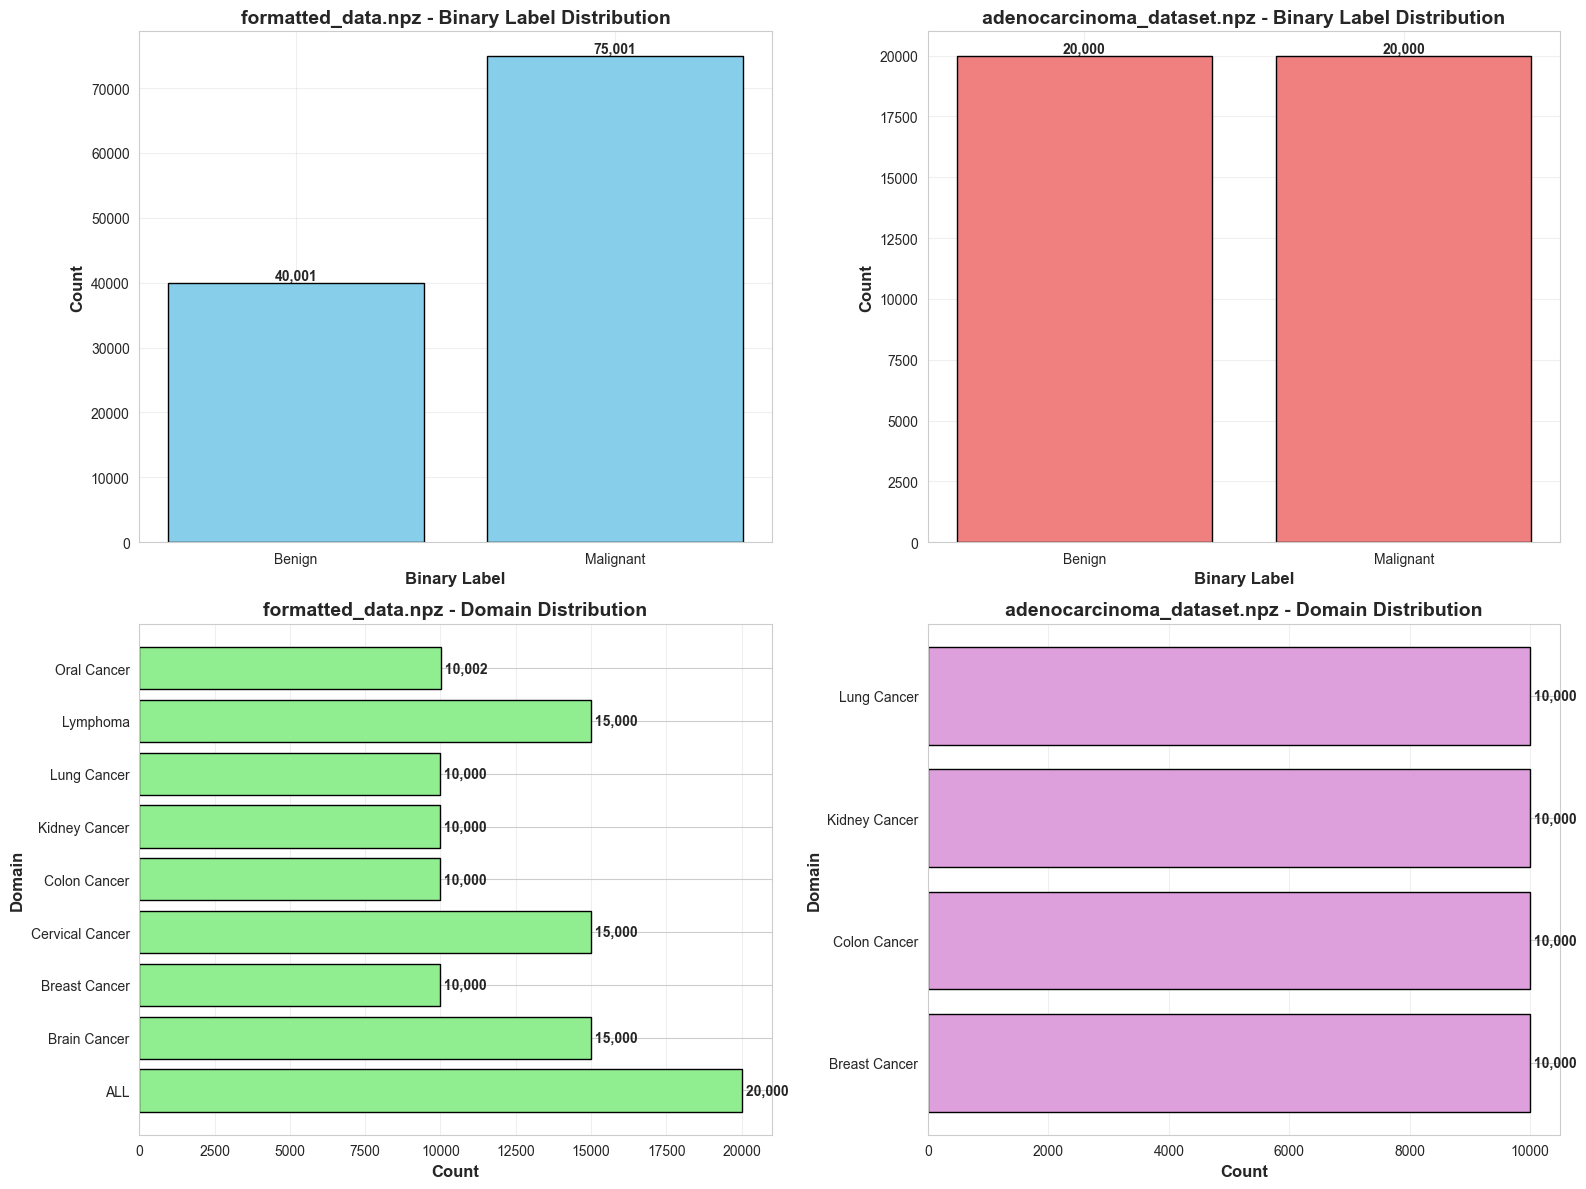

✅ Visualization saved as 'dataset_label_comparison.png'


In [19]:
# Visualize label distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: formatted_data labels2 (binary) distribution
if os.path.exists(formatted_data_path):
    ax1 = axes[0, 0]
    labels_f, counts_f = zip(*sorted(label2_counts.items()))
    ax1.bar(labels_f, counts_f, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Binary Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('formatted_data.npz - Binary Label Distribution', fontsize=14, fontweight='bold')
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Benign', 'Malignant'])
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (label, count) in enumerate(zip(labels_f, counts_f)):
        ax1.text(label, count, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Plot 2: adenocarcinoma_dataset labels2 (binary) distribution
if os.path.exists(adenocarcinoma_path):
    ax2 = axes[0, 1]
    labels_a, counts_a = zip(*sorted(label2_counts_adeno.items()))
    ax2.bar(labels_a, counts_a, color='lightcoral', edgecolor='black')
    ax2.set_xlabel('Binary Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.set_title('adenocarcinoma_dataset.npz - Binary Label Distribution', fontsize=14, fontweight='bold')
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(['Benign', 'Malignant'])
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (label, count) in enumerate(zip(labels_a, counts_a)):
        ax2.text(label, count, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Plot 3: formatted_data domain distribution
if os.path.exists(formatted_data_path):
    ax3 = axes[1, 0]
    domains_f, counts_f = zip(*sorted(domain_counts.items()))
    ax3.barh(domains_f, counts_f, color='lightgreen', edgecolor='black')
    ax3.set_xlabel('Count', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Domain', fontsize=12, fontweight='bold')
    ax3.set_title('formatted_data.npz - Domain Distribution', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (domain, count) in enumerate(zip(domains_f, counts_f)):
        ax3.text(count, i, f' {count:,}', va='center', fontweight='bold')

# Plot 4: adenocarcinoma_dataset domain distribution
if os.path.exists(adenocarcinoma_path):
    ax4 = axes[1, 1]
    domains_a, counts_a = zip(*sorted(domain_counts_adeno.items()))
    ax4.barh(domains_a, counts_a, color='plum', edgecolor='black')
    ax4.set_xlabel('Count', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Domain', fontsize=12, fontweight='bold')
    ax4.set_title('adenocarcinoma_dataset.npz - Domain Distribution', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (domain, count) in enumerate(zip(domains_a, counts_a)):
        ax4.text(count, i, f' {count:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_label_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'dataset_label_comparison.png'")

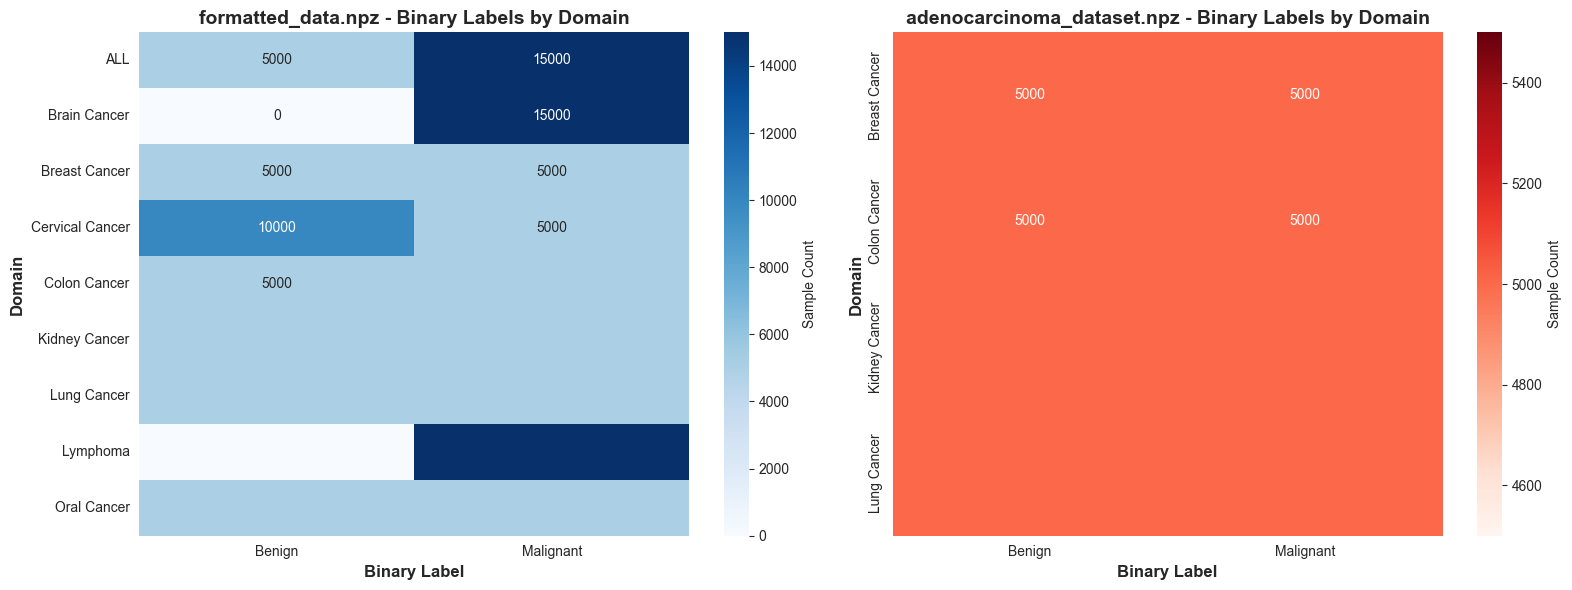

✅ Heatmap saved as 'label_domain_heatmap.png'


In [21]:
# Create heatmap for label distribution by domain
if os.path.exists(formatted_data_path) and os.path.exists(adenocarcinoma_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap 1: formatted_data
    ax1 = axes[0]
    label_domain_matrix_f = pd.crosstab(df_formatted['domain'], df_formatted['label2'])
    label_domain_matrix_f.columns = ['Benign', 'Malignant']  # Rename columns for clarity
    sns.heatmap(label_domain_matrix_f, annot=True, fmt='d', cmap='Blues', ax=ax1, 
                cbar_kws={'label': 'Sample Count'})
    ax1.set_title('formatted_data.npz - Binary Labels by Domain', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Binary Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Domain', fontsize=12, fontweight='bold')
    
    # Heatmap 2: adenocarcinoma_dataset
    ax2 = axes[1]
    label_domain_matrix_a = pd.crosstab(df_adeno['domain'], df_adeno['label2'])
    label_domain_matrix_a.columns = ['Benign', 'Malignant']  # Rename columns for clarity
    sns.heatmap(label_domain_matrix_a, annot=True, fmt='d', cmap='Reds', ax=ax2,
                cbar_kws={'label': 'Sample Count'})
    ax2.set_title('adenocarcinoma_dataset.npz - Binary Labels by Domain', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Binary Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Domain', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('label_domain_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Heatmap saved as 'label_domain_heatmap.png'")

## 6. Summary Report

Generate a comprehensive summary of findings.

In [23]:
# Generate summary report
print("📋 DATASET LABELS REVIEW - SUMMARY REPORT")
print("=" * 80)
print()

if os.path.exists(formatted_data_path):
    print("📊 formatted_data.npz Summary:")
    print("-" * 40)
    print(f"  Total Samples: {len(formatted_labels1):,}")
    print(f"  Unique Labels1 (Class IDs): {sorted(unique_labels1)}")
    print(f"  Unique Labels2 (Binary): {sorted(unique_labels2)} (0=benign, 1=malignant)")
    print(f"  Domains: {len(unique_domains)} ({', '.join(unique_domains)})")
    print(f"  Sub-domains: {len(unique_subdomains)}")
    print(f"  Binary Label Balance: ", end="")
    
    # Check if binary labels are balanced
    label2_counts_list = list(label2_counts.values())
    if len(set(label2_counts_list)) == 1:
        print("✅ Perfectly balanced")
    elif max(label2_counts_list) / min(label2_counts_list) < 1.5:
        print("⚖️ Well balanced")
    else:
        print("⚠️ Imbalanced")
    print()

if os.path.exists(adenocarcinoma_path):
    print("📊 adenocarcinoma_dataset.npz Summary:")
    print("-" * 40)
    print(f"  Total Samples: {len(adeno_labels1):,}")
    print(f"  Unique Labels1 (Class IDs): {sorted(unique_labels1_adeno)}")
    print(f"  Unique Labels2 (Binary): {sorted(unique_labels2_adeno)} (0=benign, 1=malignant)")
    print(f"  Domains: {len(unique_domains_adeno)} ({', '.join(unique_domains_adeno)})")
    print(f"  Sub-domains: {len(unique_subdomains_adeno)}")
    print(f"  Binary Label Balance: ", end="")
    
    # Check if binary labels are balanced
    label2_counts_adeno_list = list(label2_counts_adeno.values())
    if len(set(label2_counts_adeno_list)) == 1:
        print("✅ Perfectly balanced")
    elif max(label2_counts_adeno_list) / min(label2_counts_adeno_list) < 1.5:
        print("⚖️ Well balanced")
    else:
        print("⚠️ Imbalanced")
    print()

if os.path.exists(formatted_data_path) and os.path.exists(adenocarcinoma_path):
    print("🔍 Key Differences:")
    print("-" * 40)
    
    sample_diff = len(formatted_labels1) - len(adeno_labels1)
    if sample_diff > 0:
        print(f"  • formatted_data has {sample_diff:,} more samples")
    elif sample_diff < 0:
        print(f"  • adenocarcinoma_dataset has {abs(sample_diff):,} more samples")
    else:
        print(f"  • Both datasets have the same number of samples")
    
    domain_diff = len(unique_domains) - len(unique_domains_adeno)
    if domain_diff > 0:
        print(f"  • formatted_data has {domain_diff} more domain(s)")
    elif domain_diff < 0:
        print(f"  • adenocarcinoma_dataset has {abs(domain_diff)} more domain(s)")
    else:
        print(f"  • Both datasets have the same number of domains")
    
    # Label encoding comparison
    print(f"  • Labels1 encoding: ", end="")
    if set(unique_labels1) == set(unique_labels1_adeno):
        print("✅ Consistent")
    else:
        print("⚠️ Different")
    
    print(f"  • Labels2 encoding: ", end="")
    if set(unique_labels2) == set(unique_labels2_adeno):
        print("✅ Consistent")
    else:
        print("⚠️ Different")

print()
print("✅ Review Complete!")
print("=" * 80)

📋 DATASET LABELS REVIEW - SUMMARY REPORT

📊 formatted_data.npz Summary:
----------------------------------------
  Total Samples: 115,002
  Unique Labels1 (Class IDs): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  Unique Labels2 (Binary): [0, 1] (0=benign, 1=malignant)
  Domains: 9 (ALL, Brain Cancer, Breast Cancer, Cervical Cancer, Colon Cancer, Kidney Cancer, Lung Cancer, Lymphoma, Oral Cancer)
  Sub-domains: 23
  Binary Label Balance: ⚠️ Imbalanced

📊 adenocarcinoma_dataset.npz Summary:
----------------------------------------
  Total Samples: 40,000
  Unique Labels1 (Class IDs): [7, 8, 12, 13, 14, 15, 16, 17]
  Unique Labels2 (Binary): [0, 1] (0=benign, 1=malignant)
  Domains: 4 (Breast Cancer, Colon Cancer, Kidney Cancer, Lung Cancer)
  Sub-domains: 8
  Binary Label Balance: ✅ Perfectly balanced

🔍 Key Differences:
----------------------------------------
  • formatted_data has 75,002 more samples
  • formatted_data has 5 more domain(s)
  • L